In [ ]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import matplotlib.animation as anim

import os 
import sys
module_path = os.path.abspath('../')
if module_path not in sys.path:
    sys.path.append(module_path)
from GPU_solver.SystemSolverGPU import SolverGPU


In [2]:
Nx = 30*2*2
Ny = 30*2*2
L  = 60
H  = 60
chi = 20
y =np.linspace(0,H, Ny)
x =np.linspace(0,L, Nx)
xx, yy = np.meshgrid(x,y)
w0 = 10**-1

Q = 0.01 # v0*1сек*w*chi

v0 = Q/w0/chi*0

v_in = v0*np.where(np.abs(y-H/2)<chi/2, 1, 0)
v_in = (v_in + v_in[::-1])/2
v_out = np.mean(v_in)

init_params_structured = {
    'grid': {
        'Nt': 300+1,
        'Ny': Ny, 
        'Nx': Nx,
        'L': L,
        'H': H,
        'dT': 10,
    },
    'physics': {
        'beta': 2.5,
        'mu0': 0.001,
        'cmax': 0.635,
        'rho1': 1.0,
        'rho2': 2.7,
        'g': 9.8066,
        'r': 10**-3*2,
    },
    'numerics': {
        'CFL': 0.4,
        'rk_stages': 3,
        'lim_type': 'superbee',
        'kappa': -1,
        'WENO_type': 'Z',
        'use_WENO': False,
        'prefer_CG': True,
        'prefer_async_CG': True,
        'async_check_interval': 100,
        'eps': 10**-6,
        'max_iter': 10**5,
    },
    'boundary_conditions': {
        'v_in': v_in,
        'v_out': v_out,
        'c_in_times': np.array([200, 400, 600, 800, 1000, 1200]),
        'c_in_arr':   np.array([0.4, 0.0, 0.4, 0.0, 0.4 ,0.0,0]),
    }
}

v0

0.0

In [3]:
c0 = np.zeros(shape=(Ny, Nx))
c0 += - np.tanh(100*(xx-L/2-10)) + np.tanh(100*(xx-L/2+10))
c0 *= - np.tanh(100*(yy-H/2-10)) + np.tanh(100*(yy-H/2+10))
c0 /= 10 
# c0 *= 0 
s = SolverGPU(init_params_structured)
s.Vst

-0.014818862222222224

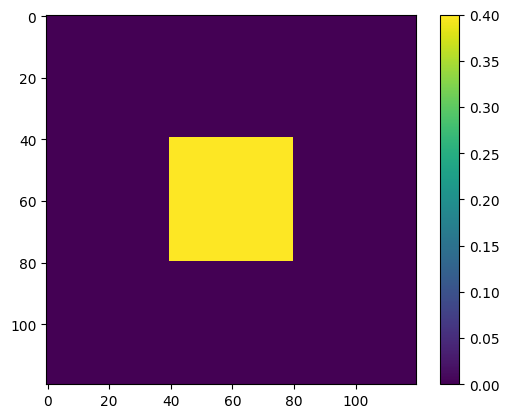

In [4]:
plt.imshow(c0)
plt.colorbar()

In [5]:
s.set_w(w0*cp.ones((s.Ny,s.Nx)))
s.apply_IC(c0)

In [6]:
s.PressureSolver.get_solver_stats()

{'iterations': 450, 'final_residual': 2.624008184946405e-08, 'converged': True}

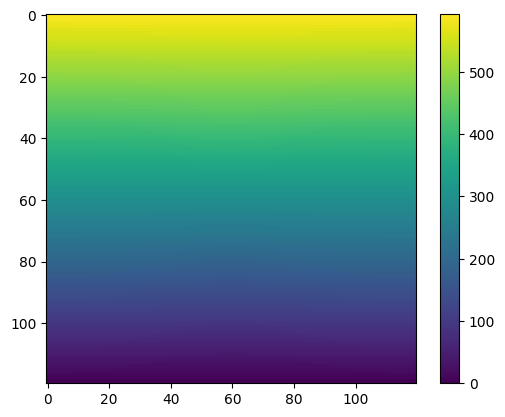

In [7]:
plt.imshow(s.P[0])
plt.colorbar()

In [8]:
s.solve(3000)

Solving:   0%|          | 0/300 [00:00<?, ?step/s]

KeyboardInterrupt: 

In [9]:
Q*200*3*0.4

2.4000000000000004

(array(90.), 15.999999999999625)

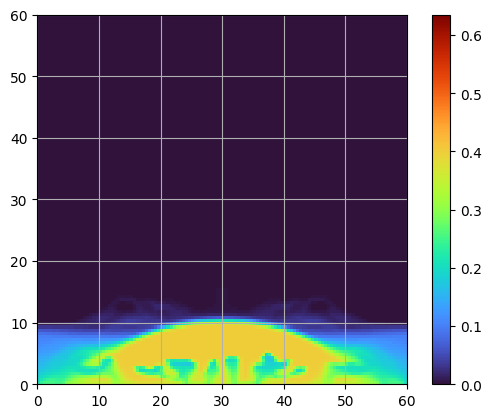

In [18]:
m = 9 #s.step

plt.imshow(s.Q[m]/s.w.get(), cmap='turbo', vmin=0, vmax=s.cmax, extent=[0, s.L, s.H, 0])
plt.colorbar()
plt.gca().invert_yaxis()
plt.grid()

s.times[m] ,np.sum(s.Q[m]*s.dx*s.dy)


0.027051210673508796

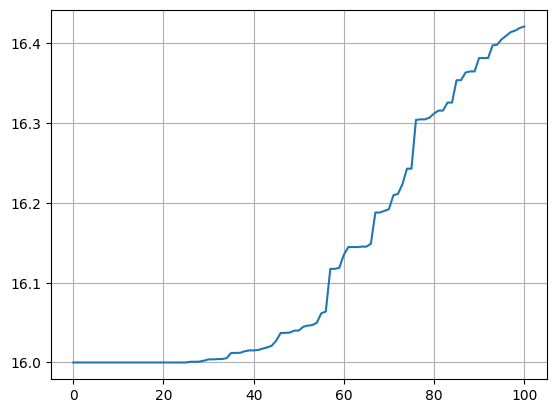

In [11]:
plt.plot([np.sum(Q*s.dx*s.dy) for Q in s.Q[:s.step]])
plt.grid()
# plt.xlim(100)
# plt.ylim(2.39, 2.41)

np.sum(s.Q[s.step])/np.sum(s.Q[0]) - 1

MovieWriter ffmpeg unavailable; using Pillow instead.


IndexError: list index out of range

Error in callback <function _draw_all_if_interactive at 0x7f12cf872dc0> (for post_execute), with arguments args (),kwargs {}:


DeprecationWarning: Please use `round` instead.

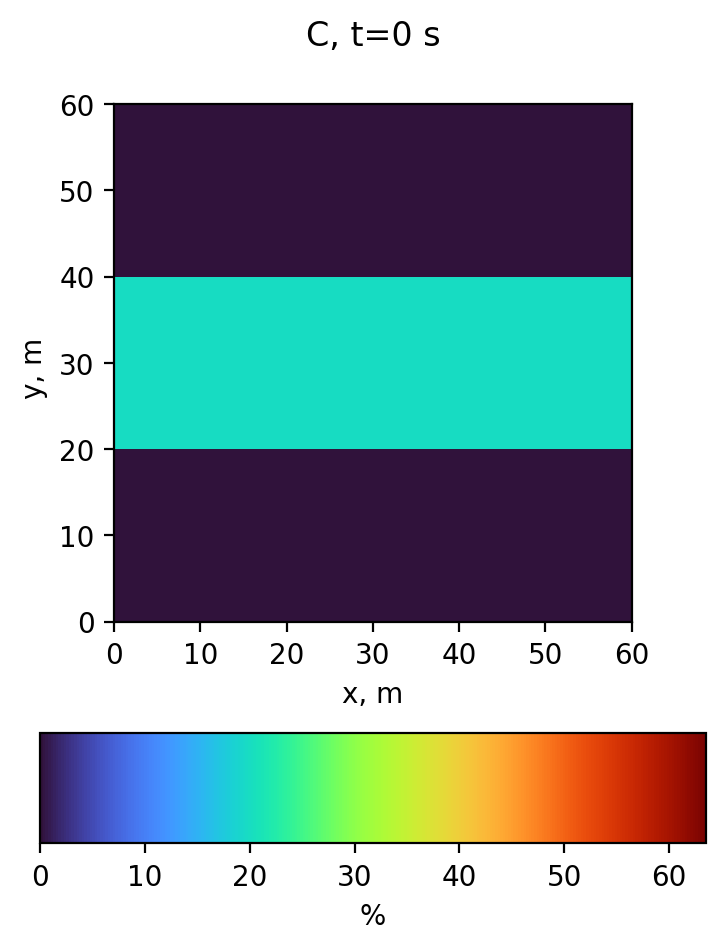

In [29]:
fig, ax = plt.subplots(1,1,dpi=200)
fig.suptitle(f'C, t=0 s')

imC = ax.imshow(100*s.Q[0]/s.w.get(), extent=[0,s.L,s.H,0], cmap='turbo',vmin=0, vmax=100*s.cmax, interpolation=None)
ax.set_xlabel('x, m')
ax.set_ylabel('y, m ')
ax.invert_yaxis()
fig.colorbar(imC, ax=ax, label='%', aspect=6, orientation='horizontal')


plt.tight_layout()
# plt.show()
def update(k):
    fig.suptitle(f'C, t={np.round(s.times[k])} s')
    imC.set_data(100*s.Q[k]/s.w)
ani = anim.FuncAnimation(fig=fig, func=update, frames=s.Nt, interval=s.dT)
ani.save(f'lim={s.TransportSolver.TVDreconstructor.lim_type},_weno={s.TransportSolver.use_WENO},_weno_type={s.TransportSolver.WENOreconstructor.type}.gif')
plt.show()